# **Tutorial 3** $\cdot$ Counterfactual Explanations

> **Abstract.** To be written at the end.


**💾 Dataset.** This notebook will make use of the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) 
dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1). Its a curated dataset consisting of roughly ten thousand 
small molecules annotated with experimentally determined [water solubility](https://en.wikipedia.org/wiki/Solubility) values. These target annotations were curated and consolidated from 
various sources throughout the literature. Due to it's experimental nature and the presence of measurement noise, it is important to note that 
it is impossible to achieve perfect prediction accuracy for this dataset. Based on results from the literature, the practical limit to the 
performance likely is a predictivity (R² score) in the range between 0.86 and 0.89.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and molecular manipulation.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of neural network models.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [exmol](https://github.com/ur-whitelab/exmol) for generating counterfactual molecular explanations using the MMACE method.

In [1]:
import os
import random
import warnings

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import rdkit.Chem as Chem
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import MeanSquaredError, R2Score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from xai_chem_review import load_dataset_aqsoldb

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The `load_dataset_aqsoldb` function loads and returns the AqSolDB dataset into a pandas `DataFrame` object. Each molecule is represented as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string with a continuous water solubility value (logS).

In [2]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
print(f'Solubility statistics:')
print(data_frame['solubility'].describe())
data_frame.head()

Loaded dataset with 11024 rows
Solubility statistics:
count    11024.000000
mean        -2.880460
std          2.343010
min        -13.171900
25%         -4.286934
50%         -2.600300
75%         -1.228457
max          2.137682
Name: solubility, dtype: float64


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [3]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

After mol conversion 11022 rows remaining


## **3.1** $\cdot$ 💡 Counterfactual Explanations

The previous tutorials have introduced *attributional* explanation methods &mdash; techniques that reveal which parts of the input are most important for a model's prediction. While these methods answer the question "what did the model focus on?", they don't directly address a more intuitive question that practitioners often ask: "what would need to change to get a different prediction?"

*Counterfactual explanations* answer exactly this question. Rather than highlighting important features or substructures, counterfactual methods identify the minimal modifications to an input that would change the model's prediction to a desired outcome. In other words, they provide "what-if" scenarios that reveal the decision boundaries learned by the model. This paradigm shift from attribution to intervention offers a fundamentally different perspective on model interpretability.

**Relevance to Molecular Property Prediction.** In the context of drug discovery and molecular design, counterfactual explanations are particularly valuable. When a model predicts that a compound has poor water solubility, a counterfactual explanation would show the smallest structural modifications that would improve the predicted solubility. Unlike attributional methods that might highlight "the aromatic ring is important", counterfactuals provide *actionable* insights like "replacing this methyl group with a hydroxyl group would increase solubility by 1.5 logS units". This makes counterfactual explanations directly applicable to lead optimization and molecular design workflows.

**Comparison to Attributional Methods.** The key distinction between counterfactual and attributional explanations lies in their output format and intended use:

- **Attributional methods** (SHAP, LIME, GNNExplainer) produce importance scores over input features or substructures, answering "what matters?"
- **Counterfactual methods** produce alternative molecular structures with different predictions, answering "what would need to change?"

Both approaches are complementary. Attributional explanations help understand the model's reasoning process, while counterfactuals provide concrete suggestions for molecular modifications. In practice, the structural changes suggested by counterfactuals often align with the features identified as important by attributional methods &mdash; but presented in a more directly actionable format.

**Challenges in Molecular Counterfactuals.** Generating counterfactual explanations for molecules presents unique challenges compared to tabular or image data. The modifications must produce *chemically valid* structures that respect valence rules, aromaticity constraints, and synthetic accessibility. Simply perturbing input features (as one might do with tabular data) is not sufficient &mdash; the resulting molecules must be realistic compounds that could potentially be synthesized and tested. This requirement has led to the development of specialized algorithms for exploring chemical space around a given molecule.

## **3.2** $\cdot$ 📚 *Model Agnostic Counterfactual Compounds* (`MMACE`)

The first example method from the literature is the *Model Agnostic Counterfactual Compounds (MMACE)* approach, implemented in the [exmol](https://github.com/ur-whitelab/exmol) package by [White et al.](https://doi.org/10.26434/chemrxiv.13646574). This method leverages the **STONED** (Synthetic Transformations of Nearby Edges and Discrete neighborhoods) algorithm to systematically explore the chemical space around a given molecule and identify counterfactual examples.

**Core Methodology.** MMACE works by:
1. **Molecular Transformation**: Using STONED to generate chemically valid variants of the input molecule through systematic bond modifications, atom replacements, and structural rearrangements
2. **Model Evaluation**: Testing each generated variant with the target model to identify those with different predictions
3. **Similarity Ranking**: Ranking the counterfactual candidates by their structural similarity to the original molecule
4. **Selection**: Choosing the most similar counterfactuals that achieve the desired prediction change

**Implementation.** The `exmol` package provides a streamlined interface for generating molecular counterfactuals. The package is model-agnostic, meaning it can work with any molecular property prediction model that accepts SMILES strings as input and returns predictions. This flexibility makes it applicable to a wide range of machine learning models, from simple linear classifiers to complex neural networks.

### Graph Neural Network Model

Before generating counterfactual explanations, we need to train a molecular property prediction model. For this tutorial, we'll use a Graph Neural Network (GNN) to predict water solubility directly from molecular graph structures. This approach allows us to demonstrate how counterfactual explanations can be applied to sophisticated graph-based models for regression tasks.

We'll reuse the graph processing functions from the second tutorial, which convert molecules into graph representations suitable for GNN training. This approach provides direct access to molecular structure information, making it particularly suitable for understanding structural changes in counterfactual explanations for solubility prediction.

In [4]:
def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit atom object into a fixed-size vector representation.
    """
    atom_one_hot = np.zeros(len(supported_atoms), dtype=np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0
    
    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()
    
    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype=np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE, 
                    Chem.BondType.DOUBLE, 
                    Chem.BondType.TRIPLE, 
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit bond object into a fixed-size vector representation.
    """
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype=np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0
        
    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())
    
    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype=np.float32)


def graph_from_smiles(smiles: str,
                      atom_encoder: callable = encode_atom,
                      bond_encoder: callable = encode_bond,
                      ) -> nx.Graph:
    """
    Converts a SMILES string to a networkx Graph representation.
    """
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    g: nx.Graph = nx.Graph()
    
    # Add atoms as nodes
    for atom in mol.GetAtoms():
        node_attributes: np.ndarray = atom_encoder(atom)
        g.add_node(
            atom.GetIdx(),
            node_index=atom.GetIdx(),
            node_atom=atom.GetSymbol(), 
            node_attributes=node_attributes
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        edge_attributes: np.ndarray = bond_encoder(bond)
        g.add_edge(
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            edge_type=bond.GetBondType(),
            edge_attributes=edge_attributes,
        )

    return g


def data_from_graph(graph: nx.Graph) -> Data:
    """
    Converts a networkx Graph to a PyTorch Geometric Data object.
    """
    if graph is None:
        return None
        
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])
    edge_indices = np.array([
        (u, v) for (u, v) in graph.edges()
    ])
    edge_attributes = np.array([
        data['edge_attributes'].tolist() 
        for _, _, data in graph.edges(data=True)
    ])
    
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long) if len(edge_indices) > 0 else torch.empty((2, 0), dtype=torch.long),
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32) if len(edge_attributes) > 0 else torch.empty((0, 6), dtype=torch.float32),
    )
    
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)
    
    return data

# Test graph conversion
test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_graph = graph_from_smiles(test_smiles)
test_data = data_from_graph(test_graph)
print(f'Test molecule converted to graph with {test_data.x.shape[0]} nodes and {test_data.edge_index.shape[1]} edges')

Test molecule converted to graph with 15 nodes and 16 edges


Now we can convert all molecules in our dataset to graph representations and prepare them for GNN training:

In [5]:
# Convert molecules to graphs
data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)

# Remove molecules that couldn't be converted to graphs
data_frame = data_frame.dropna(subset=['graph']).reset_index(drop=True)

# Add labels to graphs
for idx, row in data_frame.iterrows():
    if row['graph'] is not None:
        row['graph'].graph['graph_labels'] = row['solubility']

print(f'Dataset after graph conversion: {len(data_frame)} molecules')
data_frame[['smiles', 'solubility']].head()

Dataset after graph conversion: 11022 molecules


,smiles,solubility
0,Cc1cccc(C=C)c1,-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,-6.451105
4,NC(=O)N=NC(N)=O,-3.546243


### Model Training

Next, we'll train a Graph Neural Network regressor to predict water solubility based on molecular graph structure. This model will serve as our "black-box" predictor for which we'll generate counterfactual explanations.

In [6]:
# Train-test split 
indices = list(range(len(data_frame)))
random.shuffle(indices)

# Use 80/20 split for regression
n_train = int(0.8 * len(indices))
train_indices = indices[:n_train]
test_indices = indices[n_train:]

print(f'Train set: {len(train_indices)} molecules')
print(f'Test set: {len(test_indices)} molecules')

# Create Data objects for PyTorch Geometric
data_list_train = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in train_indices
    if data_frame.iloc[idx]['graph'] is not None
]
data_list_test = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in test_indices
    if data_frame.iloc[idx]['graph'] is not None
]

loader_train = DataLoader(data_list_train, batch_size=32, shuffle=True, num_workers=4)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

Train set: 8817 molecules
Test set: 2205 molecules


In [7]:
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import SumAggregation

class SolubilityGNN(pl.LightningModule):
    """
    Graph Neural Network regressor for predicting water solubility from molecular graphs.
    """
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: list[int] = [128, 128, 128],
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 learning_rate: float = 1e-4,
                 ):
        super().__init__()
        self.save_hyperparameters()
        
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        
        # Node and edge embedding layers
        self.node_embedding = nn.Linear(input_dim, hidden_units[0])
        self.edge_embedding = nn.Linear(edge_dim, 64)
        
        # Graph convolutional layers
        self.conv_layers = nn.ModuleList()
        prev_units = hidden_units[0]
        for units in hidden_units:
            mlp = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU(),
                nn.Linear(units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            conv = GINEConv(nn=mlp, edge_dim=64)
            self.conv_layers.append(conv)
            prev_units = units
            
        # Global pooling
        self.pooling = SumAggregation()
        
        # Dense layers
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            layer = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            self.dense_layers.append(layer)
            prev_units = units
            
        self.output_layer = nn.Linear(prev_units, output_dim)
        
        # Loss and metrics for regression
        self.criterion = nn.MSELoss()
        self.mse = MeanSquaredError()
        self.r2 = R2Score()
        
    def forward(self, x, edge_index, edge_attr, batch):
        # Embedding
        node_emb = self.node_embedding(x)
        edge_emb = self.edge_embedding(edge_attr)
        
        # Graph convolutions
        for conv in self.conv_layers:
            node_emb = conv(node_emb, edge_index, edge_emb)
            
        # Global pooling
        graph_emb = self.pooling(node_emb, batch)
        
        # Dense layers
        output = graph_emb
        for dense in self.dense_layers:
            output = dense(output)
            
        output = self.output_layer(output)
        return output
    
    def predict_smiles(self, smiles: str) -> float:
        """
        Predict solubility for a SMILES string.
        This method will be used by the counterfactual explanation algorithm.
        """
        graph = graph_from_smiles(smiles)
        if graph is None:
            return 0.0  # Return neutral prediction for invalid molecules
            
        data = data_from_graph(graph)
        if data is None:
            return 0.0
            
        # Add batch dimension
        data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
        
        self.eval()
        with torch.no_grad():
            prediction = self.forward(data.x, data.edge_index, data.edge_attr, data.batch)
            return prediction.item()
    
    def predict_batch(self, smiles_list: list[str]) -> list[float]:
        """
        Predict solubility for a batch of SMILES strings.
        """
        graphs = [graph_from_smiles(smiles) for smiles in smiles_list]
        data_list = [data_from_graph(g) for g in graphs if g is not None]
        
        if not data_list:
            return [0.0] * len(smiles_list)
        
        # Create a simple loader for batch processing
        loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)
        batch = next(iter(loader))
        
        self.eval()
        with torch.no_grad():
            predictions = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            predictions = predictions.squeeze()
            
        # Handle single prediction case
        if isinstance(predictions, torch.Tensor) and predictions.dim() == 0:
            predictions = [predictions.item()]
        else:
            predictions = predictions.tolist()
            
        # Fill results for all molecules (including None graphs)
        results = []
        data_idx = 0
        for i, graph in enumerate(graphs):
            if graph is not None:
                results.append(predictions[data_idx])
                data_idx += 1
            else:
                results.append(0.0)
                
        return results
    
    def training_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        
        # Metrics
        self.mse.update(output.squeeze(), batch.y)
        self.r2.update(output.squeeze(), batch.y)
        
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        
        # Metrics
        self.mse.update(output.squeeze(), batch.y)
        self.r2.update(output.squeeze(), batch.y)
        
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def on_validation_epoch_end(self):
        self.log('val_mse', self.mse.compute(), prog_bar=True)
        self.log('val_r2', self.r2.compute(), prog_bar=True)
        self.mse.reset()
        self.r2.reset()
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)

# Initialize and test the model
model = SolubilityGNN(
    input_dim=data_list_train[0].x.shape[1],
    edge_dim=data_list_train[0].edge_attr.shape[1],
    hidden_units=[128, 128, 128],
    dense_units=[64, 32],
    output_dim=1,
)

print(f'Model initialized with {data_list_train[0].x.shape[1]} node features and {data_list_train[0].edge_attr.shape[1]} edge features')

# Test prediction functions
test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_prediction = model.predict_smiles(test_smiles)
print(f'Test prediction for {test_smiles}: {test_prediction:.3f} logS')

Model initialized with 12 node features and 6 edge features
Test prediction for CCc1ccc2nc(S(N)(=O)=O)sc2c1: -0.230 logS


In [8]:
# Train the model
trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    enable_progress_bar=True,
    logger=False  # Disable logging for cleaner output
)

trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

model.eval()
print('\nModel training completed!')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ node_embedding │ Linear           │  1.7 K │ eval │     0 │
│ 1 │ edge_embedding │ Linear           │    448 │ eval │     0 │
│ 2 │ conv_layers    │ ModuleList       │  125 K │ eval │     0 │
│ 3 │ pooling        │ SumAggregation   │      0 │ eval │     0 │
│ 4 │ dense_layers   │ ModuleList       │ 10.5 K │ eval │     0 │
│ 5 │ output_layer   │ Linear           │     33 │ eval │     0 │
│ 6 │ criterion      │ MSELoss          │      0 │ eval │     0 │
│ 7 │ mse            │ MeanSquaredError │      0 │ eval │     0 │
│ 8 │ r2             │ R2Score          │      0 │ eval │     0 │
└───┴────────────────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 138 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 138 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 47                                                                                           
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=30` reached.



Model training completed!


### Installing and Setting Up ExMol

Before we can generate counterfactual explanations, we need to install the `exmol` package. The package provides the MMACE implementation for molecular counterfactual generation.

**📝 Note.** The `exmol` package requires specific versions of RDKit and other dependencies. If you encounter installation issues, it may be necessary to create a separate conda environment with compatible package versions.

In [9]:
import exmol
# # Install exmol if not already available
# try:
#     import exmol
#     print('exmol is already installed')
# except ImportError:
#     print('Installing exmol...')
#     import subprocess
#     import sys
    
#     result = subprocess.run([sys.executable, '-m', 'pip', 'install', 'exmol'], 
#                           capture_output=True, text=True)
#     if result.returncode == 0:
#         print('Successfully installed exmol')
#         import exmol
#     else:
#         print('Failed to install exmol:', result.stderr)
        
# # Test exmol import and basic functionality
# print(f'ExMol version: {exmol.__version__ if hasattr(exmol, "__version__") else "Unknown"}')

### Generating Counterfactual Explanations

Now we can use the trained model to generate counterfactual explanations using the MMACE method. The process involves:

1. **Selecting a target molecule** for explanation
2. **Sampling the chemical space** around the molecule using STONED
3. **Evaluating candidates** with our trained model
4. **Identifying counterfactuals** that have different predictions
5. **Ranking by similarity** to find the most similar counterfactuals

In [10]:
# Define the target molecule for counterfactual analysis
# Simply change this SMILES string to analyze a different molecule
TARGET_SMILES = 'CCCCCCCCCCCCCCC'  # Pentadecane (long alkane, low solubility)

# Validate and get prediction for the target molecule
mol = Chem.MolFromSmiles(TARGET_SMILES)
if mol is None:
    raise ValueError(f"Invalid SMILES string: {TARGET_SMILES}")

selected_molecule = TARGET_SMILES
selected_prediction = model.predict_smiles(TARGET_SMILES)

print(f'Target molecule for counterfactual analysis:')
print(f'SMILES: {selected_molecule}')
print(f'Predicted solubility: {selected_prediction:.3f} logS')
print(f'Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(mol)}')

Target molecule for counterfactual analysis:
SMILES: CCCCCCCCCCCCCCC
Predicted solubility: -4.577 logS
Molecular formula: C15H32


In [11]:
# Generate counterfactual explanations using ExMol
print(f'\n🔬 Generating counterfactual explanations for:')
print(f'Target molecule: {selected_molecule}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('\nThis may take a few minutes...')

try:
    # Step 1: Sample the chemical space around the target molecule
    print('\n📊 Step 1: Sampling chemical space with STONED algorithm...')
    
    # Create a wrapper function that matches exmol's expected interface
    def prediction_function(smiles_list):
        """
        Wrapper function for our model that matches exmol's expected interface.
        ExMol expects a function that takes a list of SMILES and returns predictions.
        """
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]
        
        predictions = model.predict_batch(smiles_list)
        return np.array(predictions)
    
    # Sample molecular space using ExMol
    # The sample_space function generates molecular variants using STONED
    samples = exmol.sample_space(
        selected_molecule, 
        prediction_function,
        batched=True,  # Use batch prediction for efficiency
        num_samples=2000,  # Number of molecular variants to generate
        preset='medium'  # Preset for STONED parameters
    )
    
    print(f'Generated {len(samples)} molecular variants')
    
    # Step 2: Identify counterfactual explanations
    print('\n🎯 Step 2: Identifying counterfactual explanations...')
    
    # For regression, we look for molecules with significantly different predictions
    # Define a meaningful change threshold (e.g., 1 logS unit difference)
    prediction_threshold = 1.0
    
    # Find molecules with predictions that differ significantly from the original
    # Note: ExMol returns Example objects with attribute access (.yhat, .similarity, .smiles)
    counterfactuals = []
    for sample in samples:
        sample_pred = sample.yhat  # Use .yhat for predictions (not dictionary access)
        prediction_diff = abs(sample_pred - selected_prediction)
        
        if prediction_diff >= prediction_threshold:
            sample.prediction_change = sample_pred - selected_prediction  # Attribute assignment
            counterfactuals.append(sample)
    
    # Sort by similarity (most similar first) and limit to top 10
    counterfactuals = sorted(counterfactuals, key=lambda x: x.similarity, reverse=True)[:10]
    
    print(f'Found {len(counterfactuals)} counterfactual explanations with |ΔlogS| ≥ {prediction_threshold}')
        
except Exception as e:
    print(f'\n❌ Error generating counterfactual explanations: {e}')
    import traceback
    traceback.print_exc()
    counterfactuals = []


🔬 Generating counterfactual explanations for:
Target molecule: CCCCCCCCCCCCCCC
Original prediction: -4.577 logS

This may take a few minutes...

📊 Step 1: Sampling chemical space with STONED algorithm...


  0%|          | 0/2000 [00:00<?, ?it/s]

🥌STONED🥌 Mutations: 1:   0%|          | 0/2000 [00:00<?, ?it/s]

🥌STONED🥌 Mutations: 1:  50%|█████     | 1000/2000 [00:00<00:00, 2669.37it/s]

🥌STONED🥌 Mutations: 2:  50%|█████     | 1000/2000 [00:00<00:00, 2669.37it/s]

...

🔭Projecting...🔭:   0%|          | 0/525 [00:00<?, ?it/s]              

🥰Finishing up🥰: 100%|██████████| 525.0/525 [00:00<00:00, 3800.84it/s]

🤘Done🤘: 100%|██████████| 525.0/525 [00:00<00:00, 3451.08it/s]        

🤘Done🤘: 100%|██████████| 525.0/525 [00:00<00:00, 3431.31it/s]

Generated 525 molecular variants

🎯 Step 2: Identifying counterfactual explanations...
Found 10 counterfactual explanations with |ΔlogS| ≥ 1.0


📊 Counterfactual Explanations Analysis

🎯 Original Molecule:
SMILES: CCCCCCCCCCCCCCC
Predicted solubility: -4.577 logS
Molecular formula: C15H32
Molecular weight: 212.42
Atoms: 15 | Bonds: 14 | Rings: 0

🔄 Top Counterfactual Explanations:
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: NCCCCCCCCCCCCCC
  Solubility: -4.577 → -3.237 logS (Δ+1.340)
  Similarity: 0.792
  Formula: C14H31N
  Weight: 212.4 → 213.4 (Δ+1.0)
  Interpretation: ↑ more soluble

Counterfactual 2:
  SMILES: OCCCCCCCCCCCCCC
  Solubility: -4.577 → -3.269 logS (Δ+1.308)
  Similarity: 0.792
  Formula: C14H30O
  Weight: 212.4 → 214.4 (Δ+2.0)
  Interpretation: ↑ more soluble

Counterfactual 3:
  SMILES: CNCCCCCCCCCCCCCC
  Solubility: -4.577 → -3.254 logS (Δ+1.323)
  Similarity: 0.780
  Formula: C15H33N
  Weight: 212.4 → 227.4 (Δ+15.0)
  Interpretation: ↑ more soluble

Counterfactual 4:
  SMILES: C(CCCCCC)CCCCCCNCC
  Solubility: -4.577 → -3.391 logS (Δ+1.186)
  Similarity:

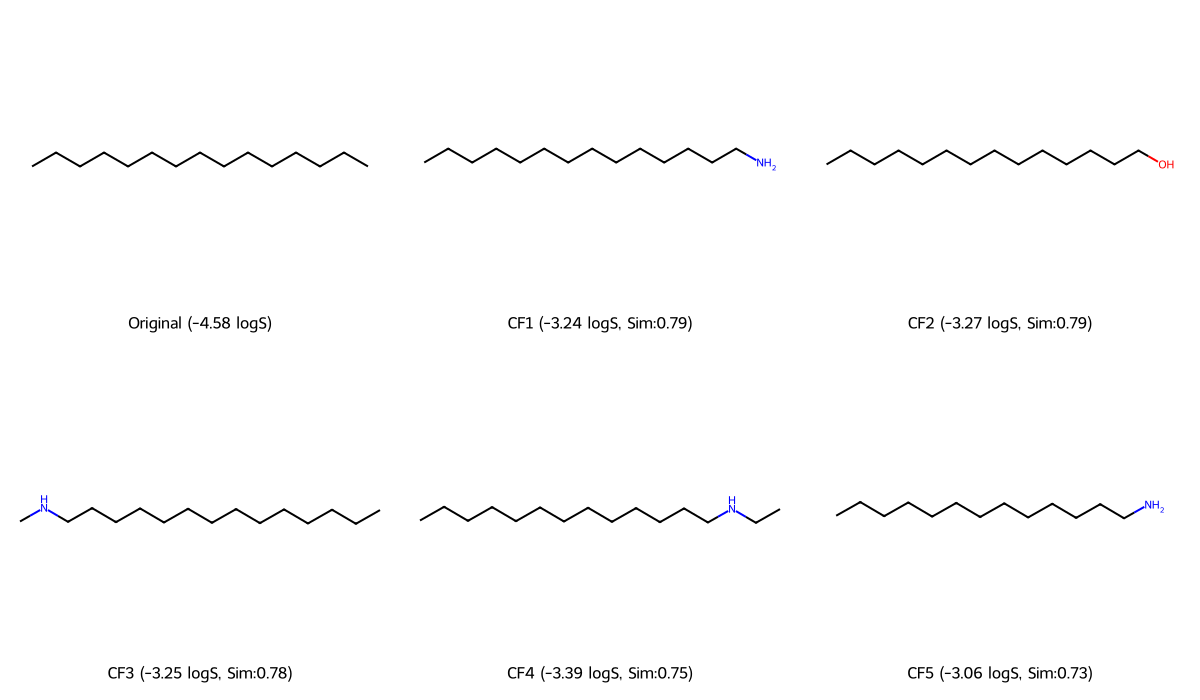


📈 Summary Statistics:
Total counterfactuals found: 10
Average similarity: 0.742 ± 0.032
Prediction range: -3.438 to -3.062 logS
Average change: +1.303 logS
Solubility increases: 10 (avg: +1.30 logS)


In [12]:
from rdkit.Chem import Draw, Descriptors
from IPython.display import display

# Display and analyze the counterfactual results
if len(counterfactuals) > 0:
    print('📊 Counterfactual Explanations Analysis')
    print('=' * 70)
    
    # Analyze the original molecule
    original_mol = Chem.MolFromSmiles(selected_molecule)
    
    print(f'\n🎯 Original Molecule:')
    print(f'SMILES: {selected_molecule}')
    print(f'Predicted solubility: {selected_prediction:.3f} logS')
    if original_mol:
        print(f'Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
        print(f'Molecular weight: {Descriptors.MolWt(original_mol):.2f}')
        print(f'Atoms: {original_mol.GetNumAtoms()} | Bonds: {original_mol.GetNumBonds()} | Rings: {Chem.rdMolDescriptors.CalcNumRings(original_mol)}')
    
    print(f'\n🔄 Top Counterfactual Explanations:')
    print('-' * 70)
    
    # Collect molecules for grid visualization
    mols_for_grid = [original_mol] if original_mol else []
    legends = [f'Original ({selected_prediction:.2f} logS)'] if original_mol else []
    
    for i, cf in enumerate(counterfactuals[:5], 1):
        cf_smiles = cf.smiles
        cf_prediction = cf.yhat
        cf_similarity = cf.similarity
        cf_change = cf.prediction_change
        
        print(f'\nCounterfactual {i}:')
        print(f'  SMILES: {cf_smiles}')
        print(f'  Solubility: {selected_prediction:.3f} → {cf_prediction:.3f} logS (Δ{cf_change:+.3f})')
        print(f'  Similarity: {cf_similarity:.3f}')
        
        cf_mol = Chem.MolFromSmiles(cf_smiles)
        if cf_mol and original_mol:
            print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')
            print(f'  Weight: {Descriptors.MolWt(original_mol):.1f} → {Descriptors.MolWt(cf_mol):.1f} (Δ{Descriptors.MolWt(cf_mol) - Descriptors.MolWt(original_mol):+.1f})')
            
            change_dir = "↑ more soluble" if cf_change > 0 else "↓ less soluble"
            print(f'  Interpretation: {change_dir}')
            
            mols_for_grid.append(cf_mol)
            legends.append(f'CF{i} ({cf_prediction:.2f} logS, Sim:{cf_similarity:.2f})')
    
    # Display molecules in a grid
    print('\n📷 Molecular Structures:')
    if mols_for_grid:
        img = Draw.MolsToGridImage(
            mols_for_grid, 
            molsPerRow=3, 
            subImgSize=(400, 350),
            legends=legends
        )
        display(img)
    
    # Summary statistics
    similarities = [cf.similarity for cf in counterfactuals]
    predictions = [cf.yhat for cf in counterfactuals]
    changes = [cf.prediction_change for cf in counterfactuals]
    
    print(f'\n📈 Summary Statistics:')
    print(f'Total counterfactuals found: {len(counterfactuals)}')
    print(f'Average similarity: {np.mean(similarities):.3f} ± {np.std(similarities):.3f}')
    print(f'Prediction range: {min(predictions):.3f} to {max(predictions):.3f} logS')
    print(f'Average change: {np.mean(changes):+.3f} logS')
    
    increases = [c for c in changes if c > 0]
    decreases = [c for c in changes if c < 0]
    if increases:
        print(f'Solubility increases: {len(increases)} (avg: +{np.mean(increases):.2f} logS)')
    if decreases:
        print(f'Solubility decreases: {len(decreases)} (avg: {np.mean(decreases):.2f} logS)')

else:
    print('❌ No counterfactual explanations found.')
    print('The molecule may be in a stable prediction region.')

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.1** $\cdot$ Try generating counterfactual explanations for a highly soluble molecule (logS > -2) from the dataset. What structural changes does the model suggest would significantly decrease its solubility? Do these changes align with known structure-solubility relationships in medicinal chemistry?

</div>

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.2** $\cdot$ Modify the MMACE parameters (number of samples, preset settings) and observe how this affects the quality and diversity of counterfactual explanations. Try different `preset` values ('fast', 'medium', 'slow') and compare the results.

</div>

## **3.3** $\cdot$ 📚 *Graph-Edit Neighborhood Counterfactuals* (`vgd-counterfactuals`)

The second counterfactual method we'll explore takes a fundamentally different approach to generating molecular counterfactuals. While MMACE uses random sampling via the STONED algorithm to explore chemical space, the [vgd-counterfactuals](https://github.com/the16thpythonist/vgd_counterfactuals) library by [Teufel *et al.*](https://github.com/the16thpythonist/vgd_counterfactuals) employs **exhaustive enumeration** of all valid molecular modifications within a given edit distance.

**Core Methodology.** The vgd-counterfactuals approach works by:
1. **Exhaustive Neighborhood Generation**: Systematically generates *all* chemically valid 1-edit modifications of the input molecule (atom additions, bond additions/modifications, bond removals)
2. **Valence Constraint Enforcement**: Each modification respects chemical valence rules using RDKit's sanitization
3. **Model Evaluation**: Predicts properties for the entire neighborhood using the target model
4. **Distance Ranking**: Ranks counterfactuals by the magnitude of prediction change
5. **Selection**: Returns the top-k modifications with the largest prediction differences

**Key Advantages.** Unlike sampling-based methods, exhaustive enumeration *guarantees* finding the optimal counterfactual within the specified edit distance. For 1-edit neighborhoods, this approach will always find the single structural change that causes the maximum prediction shift &mdash; something that random sampling might miss.

**Trade-offs.** The exhaustive approach scales exponentially with edit distance. While 1-edit neighborhoods are computationally tractable (typically hundreds to thousands of neighbors), 2-edit neighborhoods can explode to hundreds of thousands of candidates. This makes the method most suitable for understanding minimal structural changes.

### Setting Up the Counterfactual Generator

To use the vgd-counterfactuals library, we need to wrap our existing GNN model in a compatible interface. The library expects a model that can predict on graph dictionaries in the Visual Graph Datasets (VGD) format. We'll create a simple adapter class that bridges our PyTorch Geometric model with the VGD interface.

In [13]:
from vgd_counterfactuals.generate.molecules import get_neighborhood

# We'll use the neighborhood generation function directly
# and handle the prediction/ranking ourselves

def generate_exhaustive_counterfactuals(
    smiles: str, 
    model: SolubilityGNN, 
    k_results: int = 10
) -> list[dict]:
    """
    Generate counterfactuals by exhaustively enumerating all valid 1-edit 
    modifications and ranking them by prediction change.
    
    :param smiles: SMILES string of the target molecule
    :param model: Trained SolubilityGNN model
    :param k_results: Number of top counterfactuals to return
    :returns: List of counterfactual dictionaries sorted by prediction change
    """
    # Get original prediction
    original_pred = model.predict_smiles(smiles)
    
    # Generate all valid 1-edit neighbors using VGD's neighborhood function
    neighbors = get_neighborhood(smiles)
    print(f'   Generated {len(neighbors)} valid 1-edit modifications')
    
    # Predict for all neighbors and compute distances
    results = []
    for neighbor in neighbors:
        neighbor_smiles = neighbor['value']
        try:
            neighbor_pred = model.predict_smiles(neighbor_smiles)
            distance = abs(neighbor_pred - original_pred)
            
            results.append({
                'smiles': neighbor_smiles,
                'prediction': neighbor_pred,
                'distance': distance,
                'modification_type': neighbor['type'],
                'original_indices': neighbor.get('org', None),
                'modified_indices': neighbor.get('mod', None),
            })
        except Exception as e:
            # Skip molecules that cause errors
            continue
    
    # Sort by distance (largest prediction change first) and return top k
    results = sorted(results, key=lambda x: x['distance'], reverse=True)
    return results[:k_results]

print('✅ Exhaustive counterfactual generator defined')
print(f'   Using model: {model.__class__.__name__}')
print(f'   Neighborhood function: get_neighborhood (vgd_counterfactuals)')

✅ Exhaustive counterfactual generator defined
   Using model: SolubilityGNN
   Neighborhood function: get_neighborhood (vgd_counterfactuals)


### Generating Exhaustive Counterfactuals

Now we can generate counterfactuals for the same target molecule we used with MMACE. The key difference is that this method will enumerate *all* valid 1-edit modifications and guarantee finding the optimal counterfactual &mdash; the single structural change that causes the maximum prediction shift.

In [14]:
# Generate counterfactuals using exhaustive enumeration
print(f'🔬 Generating exhaustive counterfactuals for: {TARGET_SMILES}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('\nEnumerating all valid 1-edit modifications...')

# Generate counterfactuals
vgd_counterfactuals = generate_exhaustive_counterfactuals(
    smiles=TARGET_SMILES,
    model=model,
    k_results=10,
)

print(f'\n✅ Generated {len(vgd_counterfactuals)} counterfactuals')
if vgd_counterfactuals:
    print(f'   Largest prediction change: {vgd_counterfactuals[0]["distance"]:.3f} logS')
    print(f'   Smallest prediction change: {vgd_counterfactuals[-1]["distance"]:.3f} logS')

🔬 Generating exhaustive counterfactuals for: CCCCCCCCCCCCCCC
Original prediction: -4.577 logS

Enumerating all valid 1-edit modifications...
   Generated 158 valid 1-edit modifications



✅ Generated 10 counterfactuals
   Largest prediction change: 0.639 logS
   Smallest prediction change: 0.574 logS


📊 VGD Exhaustive Counterfactual Analysis

🎯 Original Molecule:
SMILES: CCCCCCCCCCCCCCC
Predicted solubility: -4.577 logS
Molecular formula: C15H32
Atoms: 15 | Bonds: 14

🔄 Top Counterfactuals (by prediction change):
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: C(CCCCCCCCCCCCCC)N
  Solubility: -4.577 → -3.938 logS (Δ+0.639)
  Modification type: add_node
  Formula: C15H33N
  Interpretation: ↑ more soluble

Counterfactual 2:
  SMILES: CC(CCCCCCCCCCCCC)N
  Solubility: -4.577 → -3.987 logS (Δ+0.590)
  Modification type: add_node
  Formula: C15H33N
  Interpretation: ↑ more soluble

Counterfactual 3:
  SMILES: CCCCCCCCCCCCCCCN
  Solubility: -4.577 → -3.993 logS (Δ+0.584)
  Modification type: add_node
  Formula: C15H33N
  Interpretation: ↑ more soluble

Counterfactual 4:
  SMILES: CCCCCCCCC(CCCCCC)N
  Solubility: -4.577 → -4.003 logS (Δ+0.574)
  Modification type: add_node
  Formula: C15H33N
  Interpretation: ↑ more soluble

Counterfactual

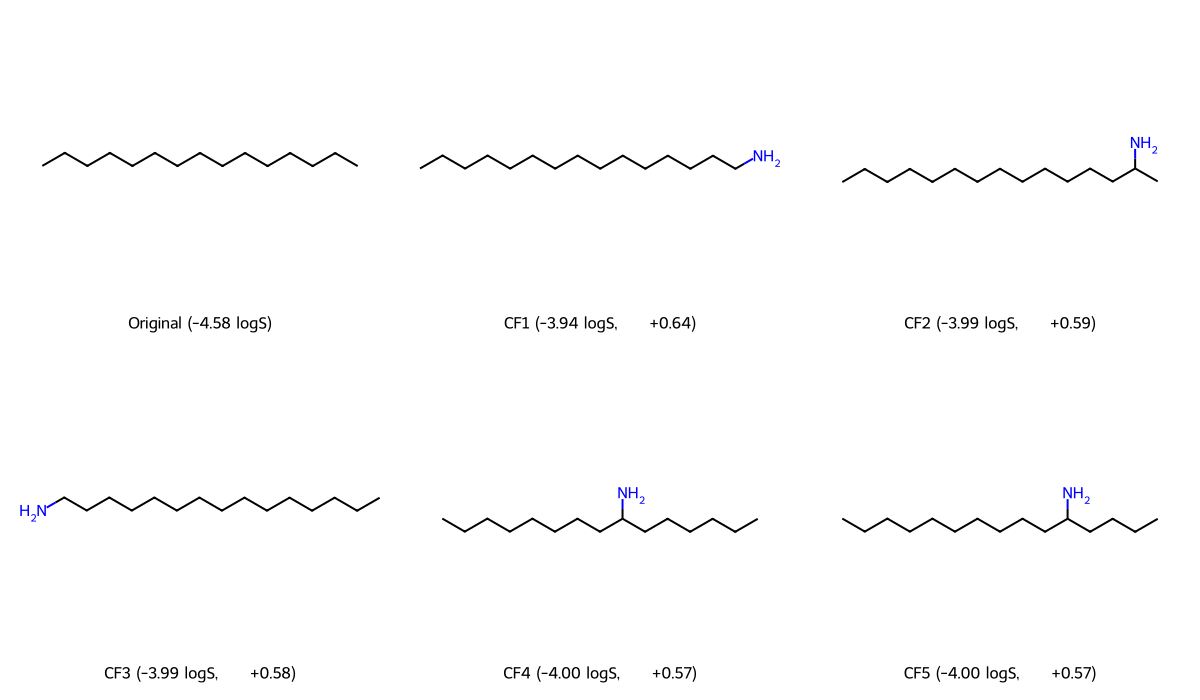


📈 Summary Statistics:
Total counterfactuals: 10
Prediction change range: 0.574 to 0.639 logS
Average change: 0.583 ± 0.019 logS
Modification types: {'add_node': 10}


In [15]:
# Visualize and analyze VGD counterfactuals
print('📊 VGD Exhaustive Counterfactual Analysis')
print('=' * 70)

print(f'\n🎯 Original Molecule:')
print(f'SMILES: {TARGET_SMILES}')
print(f'Predicted solubility: {selected_prediction:.3f} logS')

original_mol = Chem.MolFromSmiles(TARGET_SMILES)
if original_mol:
    print(f'Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
    print(f'Atoms: {original_mol.GetNumAtoms()} | Bonds: {original_mol.GetNumBonds()}')

print(f'\n🔄 Top Counterfactuals (by prediction change):')
print('-' * 70)

# Collect molecules for grid visualization
vgd_mols_for_grid = [original_mol] if original_mol else []
vgd_legends = [f'Original ({selected_prediction:.2f} logS)'] if original_mol else []

for i, cf in enumerate(vgd_counterfactuals[:5], 1):
    cf_smiles = cf['smiles']
    cf_prediction = cf['prediction']
    cf_distance = cf['distance']
    cf_type = cf['modification_type']
    cf_change = cf_prediction - selected_prediction
    
    print(f'\nCounterfactual {i}:')
    print(f'  SMILES: {cf_smiles}')
    print(f'  Solubility: {selected_prediction:.3f} → {cf_prediction:.3f} logS (Δ{cf_change:+.3f})')
    print(f'  Modification type: {cf_type}')
    
    cf_mol = Chem.MolFromSmiles(cf_smiles)
    if cf_mol and original_mol:
        print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')
        change_dir = "↑ more soluble" if cf_change > 0 else "↓ less soluble"
        print(f'  Interpretation: {change_dir}')
        
        vgd_mols_for_grid.append(cf_mol)
        vgd_legends.append(f'CF{i} ({cf_prediction:.2f} logS, Δ{cf_change:+.2f})')

# Display molecules in a grid
print('\n📷 Molecular Structures:')
if vgd_mols_for_grid:
    img = Draw.MolsToGridImage(
        vgd_mols_for_grid, 
        molsPerRow=3, 
        subImgSize=(400, 350),
        legends=vgd_legends
    )
    display(img)

# Summary statistics
print(f'\n📈 Summary Statistics:')
print(f'Total counterfactuals: {len(vgd_counterfactuals)}')
distances = [cf['distance'] for cf in vgd_counterfactuals]
print(f'Prediction change range: {min(distances):.3f} to {max(distances):.3f} logS')
print(f'Average change: {np.mean(distances):.3f} ± {np.std(distances):.3f} logS')

# Count modification types
mod_types = {}
for cf in vgd_counterfactuals:
    t = cf['modification_type']
    mod_types[t] = mod_types.get(t, 0) + 1
print(f'Modification types: {mod_types}')

### Comparing MMACE vs Exhaustive Enumeration

Now let's directly compare the counterfactuals generated by both methods. This comparison highlights the fundamental trade-off between sampling-based and exhaustive approaches.

🔍 Comparison: MMACE (Sampling) vs VGD (Exhaustive)

📊 MMACE (STONED sampling):
   Best counterfactual: NCCCCCCCCCCCCCC
   Prediction change: Δ+1.340 logS
   Similarity: 0.792

📊 VGD (Exhaustive enumeration):
   Best counterfactual: C(CCCCCCCCCCCCCC)N
   Prediction change: Δ+0.639 logS
   Modification type: add_node

📷 Side-by-Side Comparison:


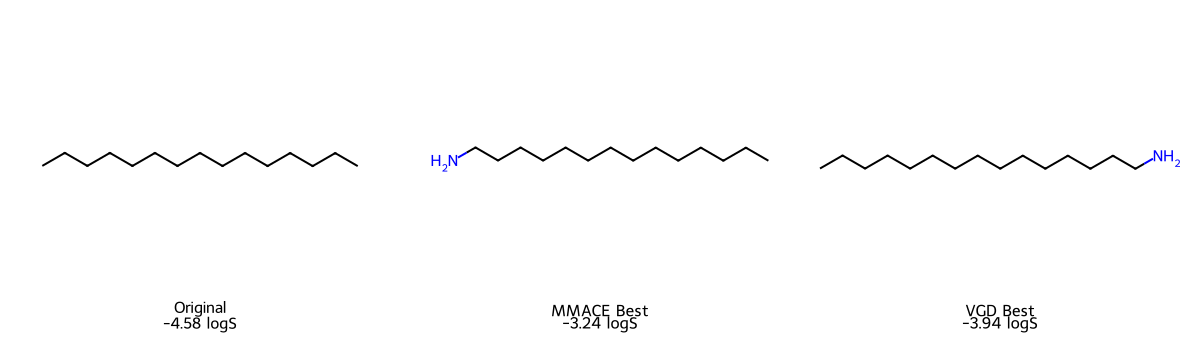


📋 Method Comparison Summary:
----------------------------------------------------------------------
Method                    Approach             Best Δ logS     Guarantee
----------------------------------------------------------------------
MMACE                     Random sampling      +1.340           Probabilistic
VGD                       Exhaustive enum.     +0.639           Optimal in 1-edit


In [16]:
# Compare MMACE and VGD counterfactuals
print('🔍 Comparison: MMACE (Sampling) vs VGD (Exhaustive)')
print('=' * 70)

# Get best counterfactual from each method
if counterfactuals:
    mmace_best = counterfactuals[0]
    mmace_change = mmace_best.prediction_change
    print(f'\n📊 MMACE (STONED sampling):')
    print(f'   Best counterfactual: {mmace_best.smiles}')
    print(f'   Prediction change: Δ{mmace_change:+.3f} logS')
    print(f'   Similarity: {mmace_best.similarity:.3f}')

if vgd_counterfactuals:
    vgd_best = vgd_counterfactuals[0]
    vgd_change = vgd_best['prediction'] - selected_prediction
    print(f'\n📊 VGD (Exhaustive enumeration):')
    print(f'   Best counterfactual: {vgd_best["smiles"]}')
    print(f'   Prediction change: Δ{vgd_change:+.3f} logS')
    print(f'   Modification type: {vgd_best["modification_type"]}')

# Visual comparison of top counterfactuals from both methods
print('\n📷 Side-by-Side Comparison:')
comparison_mols = []
comparison_legends = []

# Original
if original_mol:
    comparison_mols.append(original_mol)
    comparison_legends.append(f'Original\n{selected_prediction:.2f} logS')

# Best MMACE
if counterfactuals:
    mmace_mol = Chem.MolFromSmiles(mmace_best.smiles)
    if mmace_mol:
        comparison_mols.append(mmace_mol)
        comparison_legends.append(f'MMACE Best\n{mmace_best.yhat:.2f} logS')

# Best VGD
if vgd_counterfactuals:
    vgd_mol = Chem.MolFromSmiles(vgd_best['smiles'])
    if vgd_mol:
        comparison_mols.append(vgd_mol)
        comparison_legends.append(f'VGD Best\n{vgd_best["prediction"]:.2f} logS')

if comparison_mols:
    img = Draw.MolsToGridImage(
        comparison_mols, 
        molsPerRow=3, 
        subImgSize=(400, 350),
        legends=comparison_legends
    )
    display(img)

# Summary table
print('\n📋 Method Comparison Summary:')
print('-' * 70)
print(f'{"Method":<25} {"Approach":<20} {"Best Δ logS":<15} {"Guarantee"}')
print('-' * 70)
if counterfactuals:
    print(f'{"MMACE":<25} {"Random sampling":<20} {mmace_change:+.3f}{"":>10} {"Probabilistic"}')
if vgd_counterfactuals:
    print(f'{"VGD":<25} {"Exhaustive enum.":<20} {vgd_change:+.3f}{"":>10} {"Optimal in 1-edit"}')

**🧠 Method Comparison Insights.** The comparison between MMACE and exhaustive enumeration reveals important trade-offs:

| Aspect | MMACE (Sampling) | VGD (Exhaustive) |
|--------|------------------|------------------|
| **Search Strategy** | Random sampling via STONED | Enumerate all valid 1-edit modifications |
| **Guarantee** | Probabilistic (may miss optimal) | Guaranteed optimal within edit distance |
| **Edit Distance** | Can explore multi-edit changes | Best for 1-edit (exponential for k>1) |
| **Diversity** | Higher diversity, may find distant counterfactuals | Focuses on minimal changes |
| **Speed** | Fast for any edit distance | Fast for 1-edit, slow for k>1 |
| **Use Case** | Exploring chemical space broadly | Finding minimal required changes |

**💡 Practical Recommendations:**

1. **For lead optimization**: Use exhaustive enumeration to find the *single* modification that most improves a property
2. **For understanding model behavior**: Use MMACE to explore diverse counterfactuals across chemical space
3. **For hypothesis generation**: Combine both &mdash; exhaustive for immediate modifications, MMACE for longer-term design ideas
4. **For computational efficiency**: MMACE scales better for exploring larger structural changes

**🔬 Chemical Insights.** Both methods tend to identify similar structural features as important for solubility (polar groups, molecular size), but present them differently. Exhaustive enumeration explicitly shows "add -OH here" while MMACE might show a more distant molecule that happens to have additional polar groups.